# Chapter 4 — Core empirical results

Everything needed to write the main empirical results chapter, loaded from the **saved
run artefacts** under `outputs/`.

**This notebook does not train anything.** It reads saved run directories and the
aggregation layer. Running every cell performs no inference and mutates no run
directory.

Values are never transcribed by hand. Each table is produced by
`src.evaluation.dissertation`, which is the same module `scripts/build_dissertation_results.py`
uses for the CSV exports, so the notebook and the exports cannot disagree.

**Reporting rules in force throughout**

- Nothing is imputed: a quantity no run measured renders as `None`/`NaN`, never as zero.
- F1 is always labelled with the threshold it was measured at.
- One subset seed and one training seed were run, so **no error bars, confidence
  intervals or significance tests appear anywhere**. Differences are differences between
  two individual fits.
- A derived ratio whose denominator makes it meaningless is flagged, not silently quoted.

In [1]:
import csv
import sys
from pathlib import Path

# Locate the repository root by walking up for pyproject.toml, so the notebook works
# whether Jupyter was launched from the repo root or from this directory.
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "pyproject.toml").exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.evaluation import dissertation as D

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

OUTPUT_ROOT = REPO_ROOT / "outputs"
ctx = D.load_context(OUTPUT_ROOT)

print(f"repository root  : {REPO_ROOT}")
print(f"discovered runs  : {len(ctx.all_records)}")
print(f"reportable runs  : {len(ctx.records)}")
print(f"consolidated rows: {len(ctx.consolidated)}")

repository root  : /Users/liv.emms/MSc_Project/MSc_Project
discovered runs  : 13
reportable runs  : 8
consolidated rows: 225


## 1. Experiment inventory

One row per discovered run. Excluded runs are kept, with the reason, because which runs
were left out and why is itself something the chapter has to state.

`adaptation_pool_fakes` is only filled where the 50% budget was run, since that is the
only budget from which the pool size is directly implied; it is not extrapolated from a
smaller budget.

In [2]:
inventory = pd.DataFrame(D.experiment_inventory(ctx))
inventory[
    [
        "run_id",
        "protocol",
        "status",
        "inclusion",
        "held_out_generator",
        "head_type",
        "adaptation_depths",
        "adaptation_budgets",
        "labelled_fake_counts",
        "adaptation_pool_fakes",
        "adapted_cells",
        "total_training_hours",
        "seed",
    ]
]

,run_id,protocol,status,inclusion,held_out_generator,head_type,adaptation_depths,adaptation_budgets,labelled_fake_counts,adaptation_pool_fakes,adapted_cells,total_training_hours,seed
0,ablation-20260809T194436211721Z-fc1a22d8e3-5389,ablation,incomplete,excluded: status incomplete,biggan,linear,NaN,NaN,NaN,NaN,NaN,NaN,42
1,ablation-20260816T162529520026Z-fc1a22d8e3-f09d,ablation,incomplete,excluded: status incomplete,biggan,linear,NaN,NaN,NaN,NaN,NaN,NaN,42
2,ablation-20260816T163436467712Z-fc1a22d8e3-4f83,ablation,completed,included,biggan,linear,"full, head_only, last_block","5%, 10%, 20%, 50%","100, 200, 400, 1000","2,000.0000",12.0000,1.9200,42
3,ablation-20260823T185746201181Z-fe8a762962-59b7,ablation,completed,included,vqdm,linear,"full, head_only, last_block","5%, 10%, 20%, 50%","100, 200, 400, 1000","2,000.0000",12.0000,1.8800,42
4,baseline-20260809T150824861195Z-4c050175ac-2692,baseline,completed,included,NaN,linear,NaN,NaN,NaN,NaN,NaN,NaN,42
5,fine_tuning-20260808T144640138049Z-6ec6cf50a2-...,fine_tuning,completed,excluded: synthetic smoke run,biggan,linear,NaN,NaN,NaN,NaN,NaN,NaN,42
6,fine_tuning-20260808T171227711418Z-314210675e-...,fine_tuning,completed,included,biggan,linear,head_only,"5%, 10%, 20%, 50%",NaN,NaN,4.0000,0.5100,42
7,fine_tuning-20260816T204608740055Z-462647a0cf-...,fine_tuning,completed,included,vqdm,linear,head_only,"5%, 10%, 20%, 50%","100, 200, 400, 1000","2,000.0000",4.0000,0.3700,42
8,unseen_generator-20260808T144550443491Z-b386ea...,unseen_generator,completed,excluded: synthetic smoke run,biggan,linear,NaN,NaN,NaN,NaN,NaN,NaN,42
9,unseen_generator-20260808T150151025524Z-c74c3e...,unseen_generator,failed,excluded: status failed,biggan,linear,NaN,NaN,NaN,NaN,NaN,NaN,42


In [3]:
# Provenance and cost columns, shown separately so neither table needs sideways scrolling.
inventory[
    [
        "run_id",
        "starting_checkpoint",
        "trainable_parameter_counts",
        "total_training_seconds",
        "manifest_sha256",
        "torch_version",
    ]
].style.hide(axis="index")

run_id,starting_checkpoint,trainable_parameter_counts,total_training_seconds,manifest_sha256,torch_version
ablation-20260809T194436211721Z-fc1a22d8e3-5389,nan,nan,nan,nan,None
ablation-20260816T162529520026Z-fc1a22d8e3-f09d,nan,nan,nan,nan,None
ablation-20260816T163436467712Z-fc1a22d8e3-4f83,/Users/liv.emms/MSc_Project/MSc_Project/outputs/unseen_generator-20260808T151948963300Z-c74c3e0db3-363b/best_checkpoint.pt,"769, 7,090,177, 87,456,769",6914.500000,3a5d4aa23f77cebc514c0362da3bfe6aef0139dcb2a663285908ea83f519b415,None
ablation-20260823T185746201181Z-fe8a762962-59b7,/Users/liv.emms/MSc_Project/MSc_Project/outputs/unseen_generator-20260816T191041040059Z-4c30e188fc-e073/best_checkpoint.pt,"769, 7,090,177, 87,456,769",6758.500000,3a5d4aa23f77cebc514c0362da3bfe6aef0139dcb2a663285908ea83f519b415,None
baseline-20260809T150824861195Z-4c050175ac-2692,nan,nan,nan,nan,None
fine_tuning-20260808T144640138049Z-6ec6cf50a2-f38d,nan,nan,nan,nan,None
fine_tuning-20260808T171227711418Z-314210675e-90fa,/Users/liv.emms/MSc_Project/MSc_Project/outputs/unseen_generator-20260808T151948963300Z-c74c3e0db3-363b/best_checkpoint.pt,769,1827.400000,3a5d4aa23f77cebc514c0362da3bfe6aef0139dcb2a663285908ea83f519b415,None
fine_tuning-20260816T204608740055Z-462647a0cf-be04,/Users/liv.emms/MSc_Project/MSc_Project/outputs/unseen_generator-20260816T191041040059Z-4c30e188fc-e073/best_checkpoint.pt,769,1319.400000,3a5d4aa23f77cebc514c0362da3bfe6aef0139dcb2a663285908ea83f519b415,None
unseen_generator-20260808T144550443491Z-b386ea5c10-bb06,nan,nan,nan,nan,None
unseen_generator-20260808T150151025524Z-c74c3e0db3-21d6,nan,nan,nan,nan,None


### 1.1 What was actually run

The four completed core experiments, and the two arms of the head side-study.

In [4]:
included = inventory[inventory["inclusion"] == "included"]
print(f"included runs: {len(included)} of {len(inventory)}")
print()
for _, row in included.iterrows():
    print(f"{row['protocol']:17s} held_out={str(row['held_out_generator']):8s} "
          f"head={str(row['head_type']):7s} cells={str(row['adapted_cells']):>5s} "
          f"hours={row['total_training_hours']}")
print()
excluded = inventory[inventory["inclusion"] != "included"]
print("excluded:")
for _, row in excluded.iterrows():
    print(f"  {row['run_id']}  ->  {row['inclusion']}")

included runs: 8 of 13

ablation          held_out=biggan   head=linear  cells= 12.0 hours=1.92
ablation          held_out=vqdm     head=linear  cells= 12.0 hours=1.88
baseline          held_out=nan      head=linear  cells=  nan hours=nan
fine_tuning       held_out=biggan   head=linear  cells=  4.0 hours=0.51
fine_tuning       held_out=vqdm     head=linear  cells=  4.0 hours=0.37
unseen_generator  held_out=biggan   head=linear  cells=  nan hours=nan
unseen_generator  held_out=vqdm     head=linear  cells=  nan hours=nan
unseen_generator  held_out=vqdm     head=cosine  cells=  nan hours=nan

excluded:
  ablation-20260809T194436211721Z-fc1a22d8e3-5389  ->  excluded: status incomplete
  ablation-20260816T162529520026Z-fc1a22d8e3-f09d  ->  excluded: status incomplete
  fine_tuning-20260808T144640138049Z-6ec6cf50a2-f38d  ->  excluded: synthetic smoke run
  unseen_generator-20260808T144550443491Z-b386ea5c10-bb06  ->  excluded: synthetic smoke run
  unseen_generator-20260808T150151025524Z-c74c

## 2. Core in-distribution vs unseen results

The in-distribution reference is each run's **own prevalence-matched** test set, taken
from that run's `generalisation_gap` block. Any other in-distribution figure would be
measured at a different prevalence, which would make the gap an arithmetic artefact
rather than a generalisation result.

`head_type` is a column because this project deliberately holds out VQDM under two
different classifier heads. Without it the two arms would be indistinguishable.

In [5]:
degradation = pd.DataFrame(D.degradation_table(ctx))
view = degradation[
    ["held_out_generator", "head_type", "metric", "in_distribution", "unseen_0pct",
     "absolute_drop", "percentage_point_drop", "relative_drop_pct", "n"]
]
view.sort_values(["held_out_generator", "head_type", "metric"]).reset_index(drop=True)

,held_out_generator,head_type,metric,in_distribution,unseen_0pct,absolute_drop,percentage_point_drop,relative_drop_pct,n
0,biggan,linear,accuracy,0.8640,0.8480,0.0160,1.6000,1.8519,None
1,biggan,linear,average_precision,0.9414,0.9243,0.0171,1.7121,1.8187,None
2,biggan,linear,f1,0.8645,0.8462,0.0184,1.8388,2.1269,None
3,biggan,linear,precision,0.8611,0.8566,0.0046,0.4554,0.5288,None
4,biggan,linear,recall,0.8680,0.8360,0.0320,3.2000,3.6866,None
5,biggan,linear,roc_auc,0.9374,0.9284,0.0090,0.8960,0.9559,None
6,vqdm,cosine,accuracy,0.9000,0.6000,0.3000,30.0000,33.3333,None
7,vqdm,cosine,average_precision,0.9677,0.6872,0.2805,28.0511,28.9878,None
8,vqdm,cosine,f1,0.9004,0.4318,0.4686,46.8580,52.0414,None
9,vqdm,cosine,precision,0.8968,0.7451,0.1517,15.1727,16.9183,None


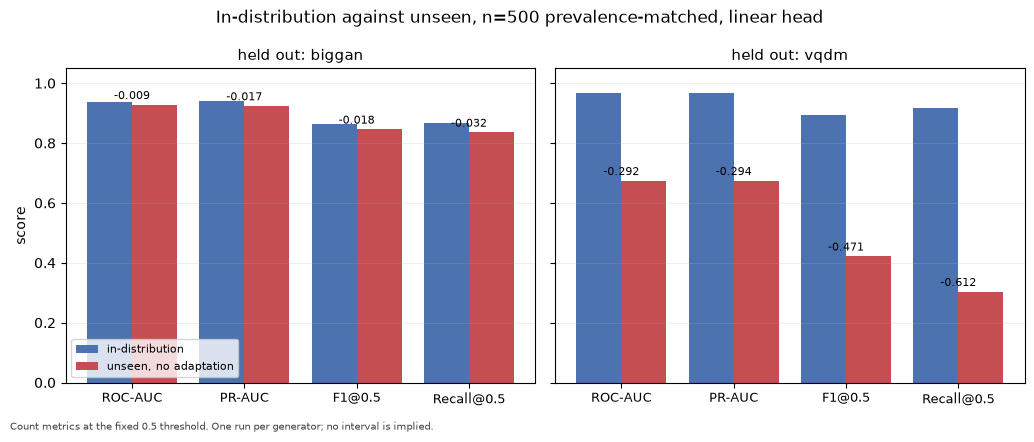

In [6]:
# Publication-quality degradation figure: both generators, the metrics that matter,
# in-distribution against unseen side by side.
linear = degradation[degradation["head_type"] == "linear"]
metrics = ["roc_auc", "average_precision", "f1", "recall"]
generators = sorted(linear["held_out_generator"].unique())

fig, axes = plt.subplots(1, len(generators), figsize=(5.2 * len(generators), 4.2), sharey=True)
axes = [axes] if len(generators) == 1 else list(axes)

for ax, generator in zip(axes, generators):
    subset = linear[linear["held_out_generator"] == generator].set_index("metric")
    subset = subset.reindex(metrics)
    x = range(len(metrics))
    ax.bar([i - 0.2 for i in x], subset["in_distribution"], width=0.4,
           label="in-distribution", color="#4C72B0")
    ax.bar([i + 0.2 for i in x], subset["unseen_0pct"], width=0.4,
           label="unseen, no adaptation", color="#C44E52")
    for i, metric in enumerate(metrics):
        drop = subset.loc[metric, "absolute_drop"]
        ax.annotate(f"-{drop:.3f}", (i, subset.loc[metric, "unseen_0pct"]),
                    textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(["ROC-AUC", "PR-AUC", "F1@0.5", "Recall@0.5"], fontsize=9)
    ax.set_title(f"held out: {generator}", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.6)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("In-distribution against unseen, n=500 prevalence-matched, linear head", fontsize=12)
fig.text(0.01, -0.02, "Count metrics at the fixed 0.5 threshold. One run per generator; "
                      "no interval is implied.", fontsize=7, color="#444444")
fig.tight_layout()
plt.show()

**Reading.** The two generators are not two samples of one phenomenon. Under an identical
protocol the BigGAN gap is roughly a hundredth of a ROC-AUC point and the VQDM gap is
nearly three tenths. Recall@0.5 is where the operational failure shows up most clearly,
and it is invisible in ROC-AUC alone.

## 3. Recovery curves

Every adaptation cell of both ablations and both standalone recovery runs, at the fixed
0.5 threshold.

`labelled_fake_images` is the count that matters for the research question: the number of
**held-out-generator** images someone had to label. `labelled_images_total` is the whole
adaptation pool including authentic images, and at the 5% budget those are 100 and 800
respectively — a distinction worth keeping straight in the prose.

In [7]:
recovery = pd.DataFrame(D.recovery_table(ctx))
recovery[
    ["held_out_generator", "protocol", "fine_tune_mode", "budget_label",
     "labelled_fake_images", "labelled_images_total", "trainable_parameters",
     "roc_auc", "average_precision", "f1", "precision", "recall", "accuracy"]
].reset_index(drop=True)

,held_out_generator,protocol,fine_tune_mode,budget_label,labelled_fake_images,labelled_images_total,trainable_parameters,roc_auc,average_precision,f1,precision,recall,accuracy
0,biggan,ablation,none,0%,0.0000,0,NaN,0.9284,0.9243,0.8462,0.8566,0.8360,0.8480
1,biggan,ablation,head_only,5%,100.0000,800,769.0000,0.9843,0.9833,0.8519,0.9894,0.7480,0.8700
2,biggan,ablation,head_only,10%,200.0000,1600,769.0000,0.9938,0.9935,0.8952,0.9856,0.8200,0.9040
3,biggan,ablation,head_only,20%,400.0000,3200,769.0000,0.9960,0.9958,0.9302,0.9865,0.8800,0.9340
4,biggan,ablation,head_only,50%,"1,000.0000",8000,769.0000,0.9975,0.9975,0.9633,0.9833,0.9440,0.9640
5,biggan,ablation,last_block,5%,100.0000,800,"7,090,177.0000",0.9876,0.9870,0.8414,0.9892,0.7320,0.8620
6,biggan,ablation,last_block,10%,200.0000,1600,"7,090,177.0000",0.9936,0.9938,0.9118,0.9860,0.8480,0.9180
7,biggan,ablation,last_block,20%,400.0000,3200,"7,090,177.0000",0.9967,0.9968,0.9436,0.9869,0.9040,0.9460
8,biggan,ablation,last_block,50%,"1,000.0000",8000,"7,090,177.0000",0.9981,0.9982,0.9778,0.9878,0.9680,0.9780
9,biggan,ablation,full,5%,100.0000,800,"87,456,769.0000",0.9985,0.9985,0.9781,0.9723,0.9840,0.9780


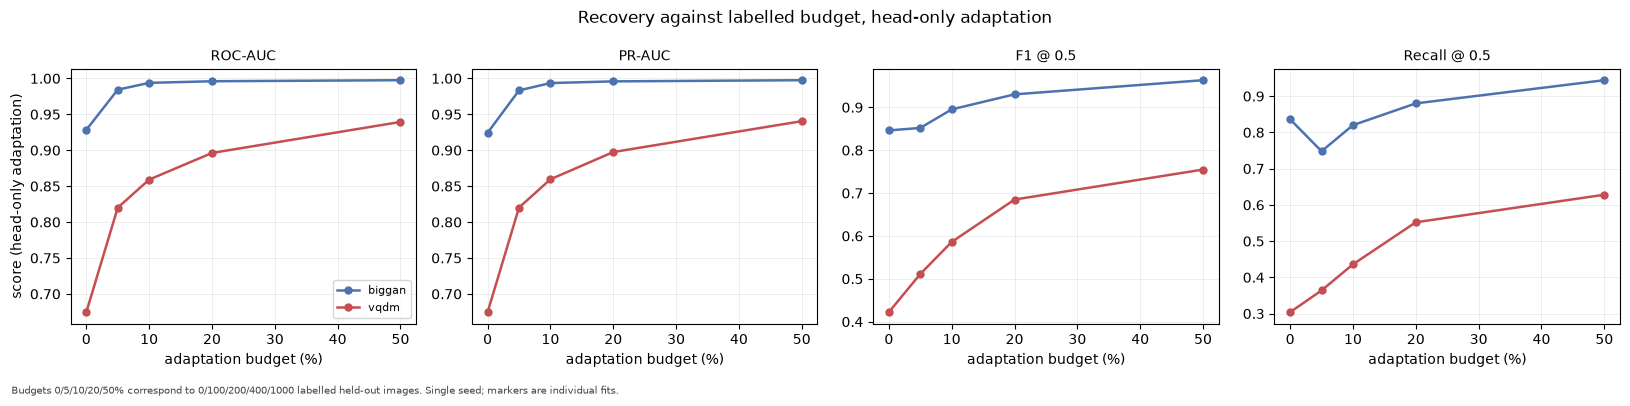

In [8]:
# Metric against budget, one panel per metric, both generators, head-only depth
# (the depth both generators have a standalone recovery run for).
metrics = [("roc_auc", "ROC-AUC"), ("average_precision", "PR-AUC"),
           ("f1", "F1 @ 0.5"), ("recall", "Recall @ 0.5")]
ablation = recovery[recovery["protocol"] == "ablation"]

fig, axes = plt.subplots(1, len(metrics), figsize=(4.1 * len(metrics), 3.8), sharex=True)
colours = {"biggan": "#4C72B0", "vqdm": "#C44E52"}

for ax, (metric, label) in zip(axes, metrics):
    for generator, colour in colours.items():
        curve = ablation[
            (ablation["held_out_generator"] == generator)
            & (ablation["fine_tune_mode"].isin(["head_only", "none"]))
        ].sort_values("adaptation_percentage")
        ax.plot(curve["adaptation_percentage"] * 100, curve[metric], marker="o",
                color=colour, label=generator, linewidth=1.8, markersize=5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("adaptation budget (%)")
    ax.grid(True, alpha=0.25, linewidth=0.6)

axes[0].set_ylabel("score (head-only adaptation)")
axes[0].legend(fontsize=8)
fig.suptitle("Recovery against labelled budget, head-only adaptation", fontsize=12)
fig.text(0.01, -0.03, "Budgets 0/5/10/20/50% correspond to 0/100/200/400/1000 labelled "
                      "held-out images. Single seed; markers are individual fits.",
         fontsize=7, color="#444444")
fig.tight_layout()
plt.show()

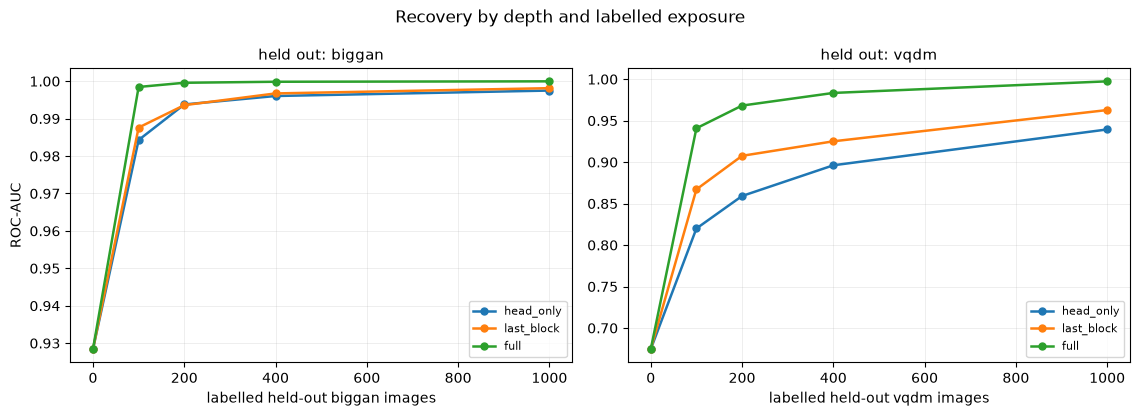

In [9]:
# Generator against recovery budget, all three depths, ROC-AUC.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=False)
for ax, generator in zip(axes, ["biggan", "vqdm"]):
    for mode in D.DEPTHS:
        curve = ablation[
            (ablation["held_out_generator"] == generator)
            & (ablation["fine_tune_mode"].isin([mode, "none"]))
        ].sort_values("adaptation_percentage")
        ax.plot(curve["labelled_fake_images"], curve["roc_auc"], marker="o",
                label=mode, linewidth=1.8, markersize=5)
    ax.set_title(f"held out: {generator}", fontsize=11)
    ax.set_xlabel(f"labelled held-out {generator} images")
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("ROC-AUC")
fig.suptitle("Recovery by depth and labelled exposure", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Marginal recovery and diminishing returns

Gain between adjacent budgets. `gain_per_labelled_fake` divides by the **additional**
held-out images that step consumed, not the cumulative total, because the question is
what the next tranche of labelling effort returns.

In [10]:
marginal = pd.DataFrame(D.marginal_recovery(ctx))
marginal.sort_values(
    ["held_out_generator", "fine_tune_mode", "metric", "from_budget"]
)[
    ["held_out_generator", "fine_tune_mode", "metric", "step", "from_value", "to_value",
     "absolute_gain", "added_labelled_fakes", "gain_per_1000_labelled_fakes",
     "fraction_of_total_recovery"]
].reset_index(drop=True)

,held_out_generator,fine_tune_mode,metric,step,from_value,to_value,absolute_gain,added_labelled_fakes,gain_per_1000_labelled_fakes,fraction_of_total_recovery
0,biggan,full,average_precision,0%->5%,0.9243,0.9985,0.0742,100,0.7420,0.9800
1,biggan,full,average_precision,5%->10%,0.9985,0.9996,0.0011,100,0.0113,0.0149
2,biggan,full,average_precision,10%->20%,0.9996,0.9999,0.0003,200,0.0014,0.0036
3,biggan,full,average_precision,20%->50%,0.9999,1.0000,0.0001,600,0.0002,0.0015
4,biggan,full,f1,0%->5%,0.8462,0.9781,0.1320,100,1.3198,0.8808
...,...,...,...,...,...,...,...,...,...,...
67,vqdm,last_block,f1,20%->50%,0.7340,0.7916,0.0576,600,0.0960,0.1559
68,vqdm,last_block,roc_auc,0%->5%,0.6746,0.8671,0.1926,100,1.9256,0.6681
69,vqdm,last_block,roc_auc,5%->10%,0.8671,0.9076,0.0405,100,0.4046,0.1404
70,vqdm,last_block,roc_auc,10%->20%,0.9076,0.9251,0.0175,200,0.0875,0.0607


In [11]:
# Proportion of the total 0->50% recovery delivered by each step, ROC-AUC.
pivot = (
    marginal[marginal["metric"] == "roc_auc"]
    .pivot_table(index=["held_out_generator", "fine_tune_mode"],
                 columns="step", values="fraction_of_total_recovery")
    .reindex(columns=["0%->5%", "5%->10%", "10%->20%", "20%->50%"])
)
(pivot * 100).round(1)

step                               0%->5%  5%->10%  10%->20%  20%->50%
held_out_generator fine_tune_mode                                     
biggan             full           97.9000   1.6000    0.4000    0.2000
                   head_only      80.9000  13.8000    3.3000    2.1000
                   last_block     84.9000   8.6000    4.5000    2.0000
vqdm               full           82.5000   8.5000    4.7000    4.3000
                   head_only      54.9000  14.8000   14.0000   16.3000
                   last_block     66.8000  14.0000    6.1000   13.1000

In [12]:
# Gain per 1,000 additional labelled held-out images, by step. The collapse across
# steps is the diminishing-returns result.
pivot_rate = (
    marginal[marginal["metric"] == "roc_auc"]
    .pivot_table(index=["held_out_generator", "fine_tune_mode"],
                 columns="step", values="gain_per_1000_labelled_fakes")
    .reindex(columns=["0%->5%", "5%->10%", "10%->20%", "20%->50%"])
)
pivot_rate.round(4)

step                               0%->5%  5%->10%  10%->20%  20%->50%
held_out_generator fine_tune_mode                                     
biggan             full            0.7005   0.0112    0.0014    0.0002
                   head_only       0.5587   0.0950    0.0113    0.0024
                   last_block      0.5920   0.0598    0.0157    0.0023
vqdm               full            2.6626   0.2734    0.0762    0.0233
                   head_only       1.4541   0.3917    0.1852    0.0720
                   last_block      1.9256   0.4046    0.0875    0.0628

### 4.1 Budget needed to reach useful performance levels

The levels below (0.90 / 0.95 / 0.98 ROC-AUC) are **reporting conveniences chosen after
the fact**, not pre-registered operational criteria, and the chapter must say so.

A level a curve never reaches is reported as *not reached*, with the best value it did
reach. Nothing is extrapolated to a budget that was never run.

In [13]:
attainment = pd.DataFrame(D.first_budget_reaching(ctx))
attainment[attainment["metric"] == "roc_auc"][
    ["held_out_generator", "fine_tune_mode", "level", "reached", "first_budget_label",
     "labelled_fakes_required", "best_value_measured", "note"]
].reset_index(drop=True)

,held_out_generator,fine_tune_mode,level,reached,first_budget_label,labelled_fakes_required,best_value_measured,note
0,biggan,head_only,0.9000,True,5%,100.0000,0.9975,reached
1,biggan,head_only,0.9500,True,5%,100.0000,0.9975,reached
2,biggan,head_only,0.9800,True,5%,100.0000,0.9975,reached
3,biggan,last_block,0.9000,True,5%,100.0000,0.9981,reached
4,biggan,last_block,0.9500,True,5%,100.0000,0.9981,reached
5,biggan,last_block,0.9800,True,5%,100.0000,0.9981,reached
6,biggan,full,0.9000,True,5%,100.0000,1.0000,reached
7,biggan,full,0.9500,True,5%,100.0000,1.0000,reached
8,biggan,full,0.9800,True,5%,100.0000,1.0000,reached
9,vqdm,head_only,0.9000,True,50%,"1,000.0000",0.9394,reached


**Reading.** This table carries the depth result more convincingly than any single
pairwise margin does. On VQDM, head-only never reaches 0.95 ROC-AUC at any budget that
was run — its ceiling after 1,000 labelled images is below the level that full
fine-tuning clears with 200.

## 5. Fine-tuning depth analysis

Three depths across four budgets, on both generators, all sharing one starting
checkpoint and one byte-identical test set per generator.

**Learning rate is not constant across depths.** `head_only` uses 1e-3 and the two
deeper modes 1e-5, a pre-declared override recorded in each run's
`controls.mode_overrides_applied`. This is a genuine confound between depth and learning
rate; it runs *against* the deeper modes, so it cannot have manufactured a
"deeper is better" result, but every depth figure in the chapter must state it.

In [14]:
depth = pd.DataFrame(D.depth_table(ctx))
depth[
    ["held_out_generator", "fine_tune_mode", "budget_label", "labelled_fake_images",
     "trainable_parameters", "learning_rate", "epochs", "best_epoch",
     "training_seconds", "roc_auc", "average_precision", "f1"]
].reset_index(drop=True)

,held_out_generator,fine_tune_mode,budget_label,labelled_fake_images,trainable_parameters,learning_rate,epochs,best_epoch,training_seconds,roc_auc,average_precision,f1
0,biggan,head_only,5%,100,769,0.0010,10,5,74.4236,0.9843,0.9833,0.8519
1,biggan,head_only,10%,200,769,0.0010,10,6,163.9942,0.9938,0.9935,0.8952
2,biggan,head_only,20%,400,769,0.0010,10,6,326.1610,0.9960,0.9958,0.9302
3,biggan,head_only,50%,1000,769,0.0010,10,5,736.5717,0.9975,0.9975,0.9633
4,biggan,last_block,5%,100,7090177,0.0000,10,4,81.0550,0.9876,0.9870,0.8414
5,biggan,last_block,10%,200,7090177,0.0000,10,4,157.0255,0.9936,0.9938,0.9118
6,biggan,last_block,20%,400,7090177,0.0000,10,5,364.7754,0.9967,0.9968,0.9436
7,biggan,last_block,50%,1000,7090177,0.0000,10,5,877.1871,0.9981,0.9982,0.9778
8,biggan,full,5%,100,87456769,0.0000,10,4,189.0883,0.9985,0.9985,0.9781
9,biggan,full,10%,200,87456769,0.0000,10,4,369.1392,0.9996,0.9996,0.9900


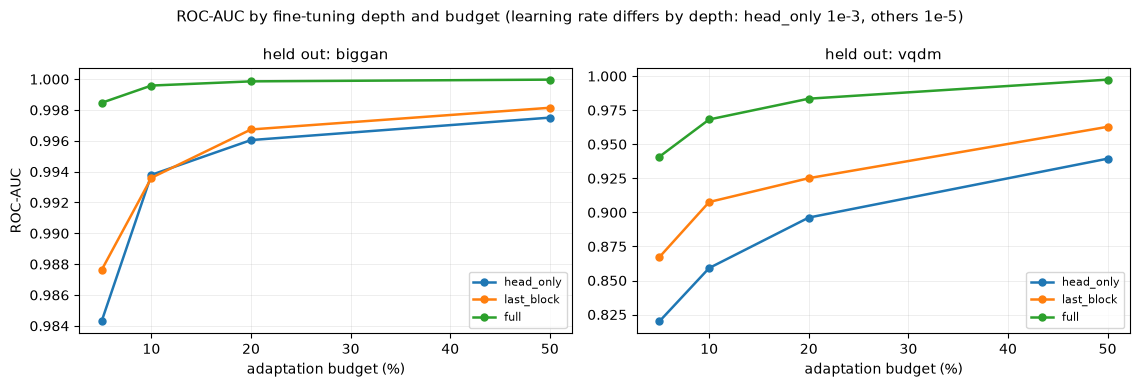

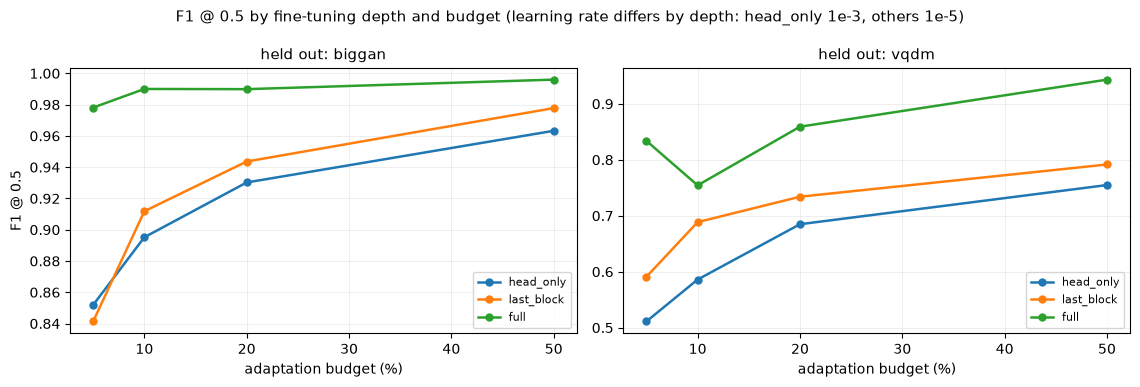

In [15]:
# Depth x budget grid, one panel per generator per metric.
for metric, label in (("roc_auc", "ROC-AUC"), ("f1", "F1 @ 0.5")):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
    for ax, generator in zip(axes, ["biggan", "vqdm"]):
        subset = depth[depth["held_out_generator"] == generator]
        for mode in D.DEPTHS:
            curve = subset[subset["fine_tune_mode"] == mode].sort_values("adaptation_percentage")
            ax.plot(curve["adaptation_percentage"] * 100, curve[metric], marker="o",
                    label=mode, linewidth=1.8, markersize=5)
        ax.set_title(f"held out: {generator}", fontsize=11)
        ax.set_xlabel("adaptation budget (%)")
        ax.grid(True, alpha=0.25, linewidth=0.6)
        ax.legend(fontsize=8, loc="lower right")
    axes[0].set_ylabel(label)
    fig.suptitle(f"{label} by fine-tuning depth and budget "
                 "(learning rate differs by depth: head_only 1e-3, others 1e-5)", fontsize=11)
    fig.tight_layout()
    plt.show()

### 5.1 The comparisons the depth argument rests on

Each row below is a claim with the two measured numbers behind it. `holds` is computed,
not assumed. `margin_above_reliability_floor` says whether the margin clears the 0.02
floor the aggregation layer already uses for `gap_closed_fraction`; below it, the honest
statement is equivalence, not superiority.

In [16]:
comparisons = pd.DataFrame(D.depth_comparisons(ctx))
headline = comparisons[comparisons["comparison"] == "full @5% vs head_only @50%"]
headline[
    ["held_out_generator", "metric", "left_value", "right_value", "difference",
     "holds", "margin_above_reliability_floor", "defensible_claim"]
].reset_index(drop=True)

,held_out_generator,metric,left_value,right_value,difference,holds,margin_above_reliability_floor,defensible_claim
0,biggan,roc_auc,0.9985,0.9975,0.0010,True,False,matches at one tenth the labelling cost
1,biggan,average_precision,0.9985,0.9975,0.0010,True,False,matches at one tenth the labelling cost
2,biggan,f1,0.9781,0.9633,0.0149,True,False,matches at one tenth the labelling cost
3,vqdm,roc_auc,0.9408,0.9394,0.0014,True,False,matches at one tenth the labelling cost
4,vqdm,average_precision,0.9461,0.9404,0.0057,True,False,matches at one tenth the labelling cost
5,vqdm,f1,0.8337,0.7548,0.0789,True,True,outperforms


In [17]:
for _, row in headline.iterrows():
    print(f"{row['held_out_generator']:8s} {row['metric']:20s} {row['statement']}")
    print(f"{'':8s} {'':20s} -> defensible claim: {row['defensible_claim']}")
    print()

biggan   roc_auc              full fine-tuning at 5% (0.9985) matches (margin below the reliability floor) head-only at 50% (0.9975) on roc_auc [+0.0010], using 100 labelled biggan images against 1000
                              -> defensible claim: matches at one tenth the labelling cost

biggan   average_precision    full fine-tuning at 5% (0.9985) matches (margin below the reliability floor) head-only at 50% (0.9975) on average_precision [+0.0010], using 100 labelled biggan images against 1000
                              -> defensible claim: matches at one tenth the labelling cost

biggan   f1                   full fine-tuning at 5% (0.9781) matches (margin below the reliability floor) head-only at 50% (0.9633) on f1 [+0.0149], using 100 labelled biggan images against 1000
                              -> defensible claim: matches at one tenth the labelling cost

vqdm     roc_auc              full fine-tuning at 5% (0.9408) matches (margin below the reliability floor) head-only

In [18]:
# Is depth ordering monotonic at each budget? Does deeper ever lose to head-only?
other = comparisons[comparisons["comparison"] != "full @5% vs head_only @50%"]
for _, row in other.iterrows():
    flag = "OK " if row["holds"] else "NO "
    print(f"{flag} {row['held_out_generator']:8s} {row['metric']:20s} {row['statement']}")

OK  biggan   roc_auc              at 5%, roc_auc runs head_only 0.9843 -> last_block 0.9876 -> full 0.9985; deeper is monotonically better
OK  biggan   average_precision    at 5%, average_precision runs head_only 0.9833 -> last_block 0.9870 -> full 0.9985; deeper is monotonically better
NO  biggan   f1                   at 5%, f1 runs head_only 0.8519 -> last_block 0.8414 -> full 0.9781; the ordering is NOT monotonic
NO  biggan   roc_auc              at 10%, roc_auc runs head_only 0.9938 -> last_block 0.9936 -> full 0.9996; the ordering is NOT monotonic
OK  biggan   average_precision    at 10%, average_precision runs head_only 0.9935 -> last_block 0.9938 -> full 0.9996; deeper is monotonically better
OK  biggan   f1                   at 10%, f1 runs head_only 0.8952 -> last_block 0.9118 -> full 0.9900; deeper is monotonically better
OK  biggan   roc_auc              at 20%, roc_auc runs head_only 0.9960 -> last_block 0.9967 -> full 0.9999; deeper is monotonically better
OK  biggan   av

**Reading.**

- On VQDM the ordering head-only < last-block < full holds at **every** budget and on
  **every** metric, and no deeper depth ever loses to head-only at an equal budget.
- On BigGAN the ordering breaks in two places. Both breaks are tiny and occur above 0.98
  ROC-AUC, which is consistent with noise at the ceiling — but with one seed there is no
  way to separate noise from a real reversal, so neither is claimed.
- The cheap-deep against dear-shallow pair is directionally consistent on all three
  metrics and both generators, but only the VQDM F1 margin clears the reliability floor.

## 6. Parameter efficiency

Gain over the 0% reference per unit of parameter, labelling and time cost.

**On excluded ratios.** A gain-per-cost ratio is only interpretable when the numerator is
large enough to be distinguished from run-to-run noise. With one seed there is no noise
estimate, so the conservative substitute is the same 0.02 floor used elsewhere. Rows
below it are exported with `efficiency_is_meaningful=False` and a stated reason rather
than deleted: dividing a near-zero gain by the 769-parameter denominator produces a
spectacular number that describes the noise floor, not the method.

In [19]:
efficiency = pd.DataFrame(D.parameter_efficiency(ctx))
efficiency[
    ["held_out_generator", "fine_tune_mode", "budget_label", "metric", "absolute_gain",
     "trainable_parameters", "gain_per_million_parameters", "gain_per_labelled_fake",
     "gain_per_training_hour", "efficiency_is_meaningful"]
].reset_index(drop=True)

,held_out_generator,fine_tune_mode,budget_label,metric,absolute_gain,trainable_parameters,gain_per_million_parameters,gain_per_labelled_fake,gain_per_training_hour,efficiency_is_meaningful
0,biggan,head_only,5%,roc_auc,0.0559,769,72.6554,0.0006,2.7026,True
1,biggan,head_only,5%,average_precision,0.0590,769,76.7426,0.0006,2.8547,True
2,biggan,head_only,5%,f1,0.0058,769,7.5193,0.0001,0.2797,False
3,biggan,head_only,10%,roc_auc,0.0654,769,85.0143,0.0003,1.4351,True
4,biggan,head_only,10%,average_precision,0.0692,769,89.9827,0.0003,1.5190,True
...,...,...,...,...,...,...,...,...,...,...
67,vqdm,full,20%,average_precision,0.3117,87456769,0.0036,0.0008,1.2428,True
68,vqdm,full,20%,f1,0.4369,87456769,0.0050,0.0011,1.7419,True
69,vqdm,full,50%,roc_auc,0.3228,87456769,0.0037,0.0003,0.5034,True
70,vqdm,full,50%,average_precision,0.3228,87456769,0.0037,0.0003,0.5034,True


In [20]:
excluded = efficiency[~efficiency["efficiency_is_meaningful"]]
print(f"rows excluded from efficiency interpretation: {len(excluded)} of {len(efficiency)}")
for _, row in excluded.iterrows():
    print(f"  {row['held_out_generator']:7s} {row['fine_tune_mode']:11s} "
          f"{row['budget_label']:4s} {row['metric']:18s} gain {row['absolute_gain']:+.4f}")
    print(f"      reason: {row['exclusion_reason']}")

rows excluded from efficiency interpretation: 2 of 72
  biggan  head_only   5%   f1                 gain +0.0058
      reason: measured gain +0.0058 is below the 0.02 reliability floor; with one seed and no variance estimate the ratio would describe the noise floor rather than the method
  biggan  last_block  5%   f1                 gain -0.0048
      reason: measured gain -0.0048 is below the 0.02 reliability floor; with one seed and no variance estimate the ratio would describe the noise floor rather than the method


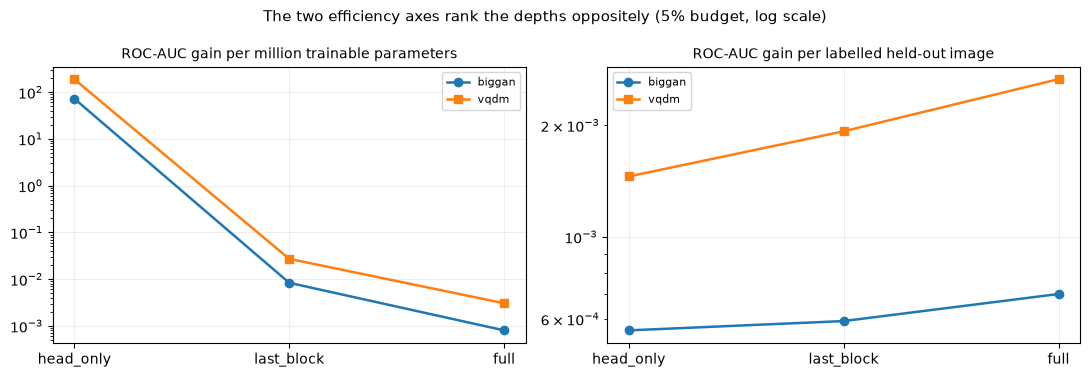

In [21]:
# The two efficiency axes, side by side, at the 5% budget on VQDM.
at5 = efficiency[
    (efficiency["metric"] == "roc_auc")
    & (efficiency["adaptation_percentage"] == 0.05)
    & (efficiency["efficiency_is_meaningful"])
]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, column, title in (
    (axes[0], "gain_per_million_parameters", "ROC-AUC gain per million trainable parameters"),
    (axes[1], "gain_per_labelled_fake", "ROC-AUC gain per labelled held-out image"),
):
    for generator, marker in (("biggan", "o"), ("vqdm", "s")):
        subset = at5[at5["held_out_generator"] == generator]
        subset = subset.set_index("fine_tune_mode").reindex(D.DEPTHS).reset_index()
        ax.plot(subset["fine_tune_mode"], subset[column], marker=marker, label=generator,
                linewidth=1.8)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=8)
fig.suptitle("The two efficiency axes rank the depths oppositely (5% budget, log scale)",
             fontsize=11)
fig.tight_layout()
plt.show()

**Reading.** Head-only wins per parameter by four to five orders of magnitude, which is
close to a restatement of the 113,728x parameter ratio and says nothing about adequacy.
Full wins per labelled image, which is the currency this project's research question is
denominated in. The honest framing is a trade-off with two named axes, not a winner.

Training-time figures are recorded but should be read narrowly: all runs are CPU-only on
one machine, so absolute durations do not transfer.

## 7. Threshold and calibration behaviour

Each cell scored at every saved operating point:

- `default` — the fixed 0.5 prior.
- `adaptation_selected` — a threshold chosen on the cell's own adaptation-validation split.
- `baseline_unchanged` — the threshold the pre-adaptation model was operating at.

Comparing the first two answers whether recalibration helps or harms on the unseen test
set. They are never mixed into one comparison elsewhere in the chapter.

In [22]:
thresholds = pd.DataFrame(D.threshold_table(ctx))
thresholds[
    ["held_out_generator", "fine_tune_mode", "budget_label", "threshold_default",
     "f1_at_default", "threshold_adaptation_selected", "f1_at_adaptation_selected",
     "recalibration_f1_delta", "recalibration_helps", "threshold_shift"]
].reset_index(drop=True)

,held_out_generator,fine_tune_mode,budget_label,threshold_default,f1_at_default,threshold_adaptation_selected,f1_at_adaptation_selected,recalibration_f1_delta,recalibration_helps,threshold_shift
0,biggan,full,5%,0.5000,0.9781,0.0300,0.9784,0.0003,True,-0.4700
1,biggan,full,10%,0.5000,0.9900,0.0200,0.9842,-0.0058,False,-0.4800
2,biggan,full,20%,0.5000,0.9899,0.0500,0.9920,0.0021,True,-0.4500
3,biggan,full,50%,0.5000,0.9960,0.8800,0.9919,-0.0040,False,0.3800
4,biggan,head_only,5%,0.5000,0.8519,0.4500,0.8552,0.0033,True,-0.0500
5,biggan,head_only,10%,0.5000,0.8952,0.3200,0.9419,0.0467,True,-0.1800
6,biggan,head_only,20%,0.5000,0.9302,0.4700,0.9372,0.0070,True,-0.0300
7,biggan,head_only,50%,0.5000,0.9633,0.5300,0.9611,-0.0021,False,0.0300
8,biggan,last_block,5%,0.5000,0.8414,0.2900,0.9165,0.0751,True,-0.2100
9,biggan,last_block,10%,0.5000,0.9118,0.1100,0.9576,0.0457,True,-0.3900


In [23]:
verdicts = pd.DataFrame(D.recalibration_verdict(ctx))
verdicts

,held_out_generator,cells_compared,cells_improved,cells_harmed,cells_unchanged,mean_f1_delta,max_improvement,max_harm,verdict
0,biggan,18,11,7,0,0.0112,0.0751,-0.0115,recalibration helps in the majority of cells
1,vqdm,18,12,5,1,0.0303,0.1516,-0.0289,recalibration helps in the majority of cells


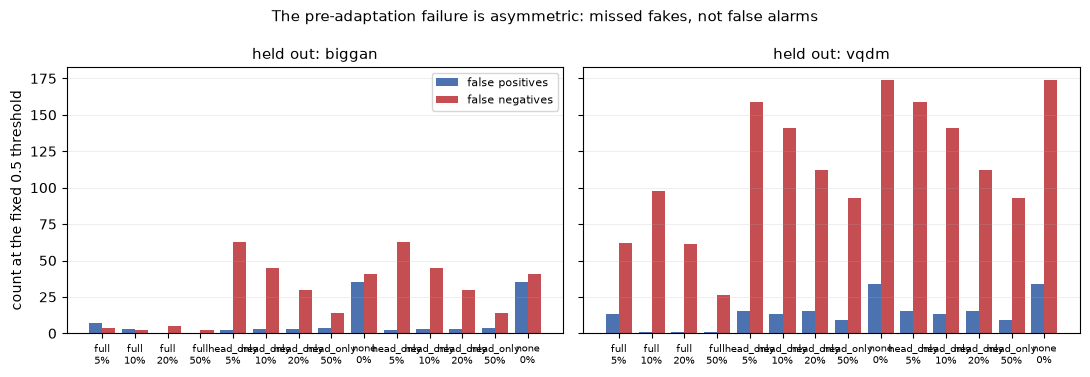

In [24]:
# False positives against false negatives, before and after adaptation.
errors = thresholds[["held_out_generator", "fine_tune_mode", "budget_label",
                     "false_positive_at_default", "false_negative_at_default"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, generator in zip(axes, ["biggan", "vqdm"]):
    subset = errors[errors["held_out_generator"] == generator]
    subset = subset[subset["fine_tune_mode"].isin(["none", "head_only", "full"])]
    labels = [f"{r.fine_tune_mode}\n{r.budget_label}" for r in subset.itertuples()]
    x = range(len(subset))
    ax.bar([i - 0.2 for i in x], subset["false_positive_at_default"], width=0.4,
           label="false positives", color="#4C72B0")
    ax.bar([i + 0.2 for i in x], subset["false_negative_at_default"], width=0.4,
           label="false negatives", color="#C44E52")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=7, rotation=0)
    ax.set_title(f"held out: {generator}", fontsize=11)
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.6)
axes[0].set_ylabel("count at the fixed 0.5 threshold")
axes[0].legend(fontsize=8)
fig.suptitle("The pre-adaptation failure is asymmetric: missed fakes, not false alarms",
             fontsize=11)
fig.tight_layout()
plt.show()

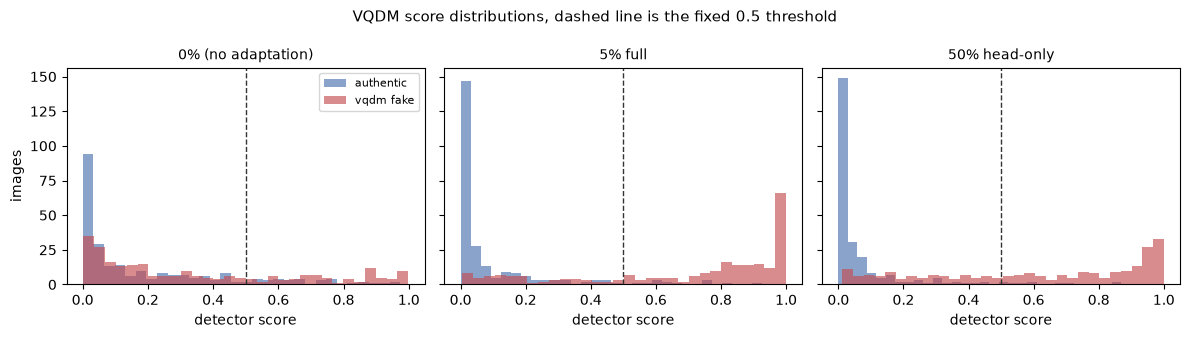

In [25]:
# Score distributions before and after adaptation, from the saved per-sample scores.
def load_scores(run_id, mode, percentage):
    path = D.prediction_path(ctx, run_id, mode, percentage)
    if path is None:
        return None
    with path.open() as handle:
        rows = list(csv.DictReader(handle))
    return pd.DataFrame(
        {"label": [int(r["label"]) for r in rows],
         "score": [float(r["score"]) for r in rows]}
    )

vqdm_run = next(r.run_id for r in ctx.ablation_runs() if ctx.held_out_of(r.run_id) == "vqdm")
panels = [("0% (no adaptation)", "none", 0.0),
          ("5% full", "full", 0.05),
          ("50% head-only", "head_only", 0.50)]

fig, axes = plt.subplots(1, len(panels), figsize=(4.0 * len(panels), 3.4), sharey=True)
for ax, (label, mode, pct) in zip(axes, panels):
    frame = load_scores(vqdm_run, mode, pct)
    if frame is None:
        ax.set_title(f"{label}\n(predictions not saved)", fontsize=9)
        continue
    ax.hist(frame[frame.label == 0]["score"], bins=30, alpha=0.65,
            label="authentic", color="#4C72B0")
    ax.hist(frame[frame.label == 1]["score"], bins=30, alpha=0.65,
            label="vqdm fake", color="#C44E52")
    ax.axvline(0.5, color="#333333", linestyle="--", linewidth=1.0)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("detector score")
axes[0].set_ylabel("images")
axes[0].legend(fontsize=8)
fig.suptitle("VQDM score distributions, dashed line is the fixed 0.5 threshold", fontsize=11)
fig.tight_layout()
plt.show()

**Reading.** At 0% the held-out fake distribution sits largely on the authentic side of
the fixed boundary while remaining separable — which is exactly why ROC-AUC stays well
above chance while recall collapses. Adaptation moves the distribution across the
boundary rather than making the classes newly separable.

Recalibration helps more often than it harms, but the mean effect is small and the spread
includes real harm. It is a partial mitigation, not a substitute for adaptation.

## 8. Confusion matrices

Five selected conditions: the failure, and the two ways of repairing it on each
generator. Shown as one panel on a shared colour scale so the counts are comparable —
five separate figures would not be.

In [26]:
confusion = pd.DataFrame(D.confusion_selection(ctx))
confusion[["label", "available", "true_negative", "false_positive", "false_negative",
           "true_positive", "recall", "precision", "f1", "roc_auc"]]

,label,available,true_negative,false_positive,false_negative,true_positive,recall,precision,f1,roc_auc
0,"BigGAN 0% (unseen, no adaptation)",True,215,35,41,209,0.8360,0.8566,0.8462,0.9284
1,BigGAN 5% head-only,True,248,2,63,187,0.7480,0.9894,0.8519,0.9843
2,"VQDM 0% (unseen, no adaptation)",True,216,34,174,76,0.3040,0.6909,0.4222,0.6746
3,VQDM 5% full,True,237,13,62,188,0.7520,0.9353,0.8337,0.9408
4,VQDM 50% head-only,True,241,9,93,157,0.6280,0.9458,0.7548,0.9394


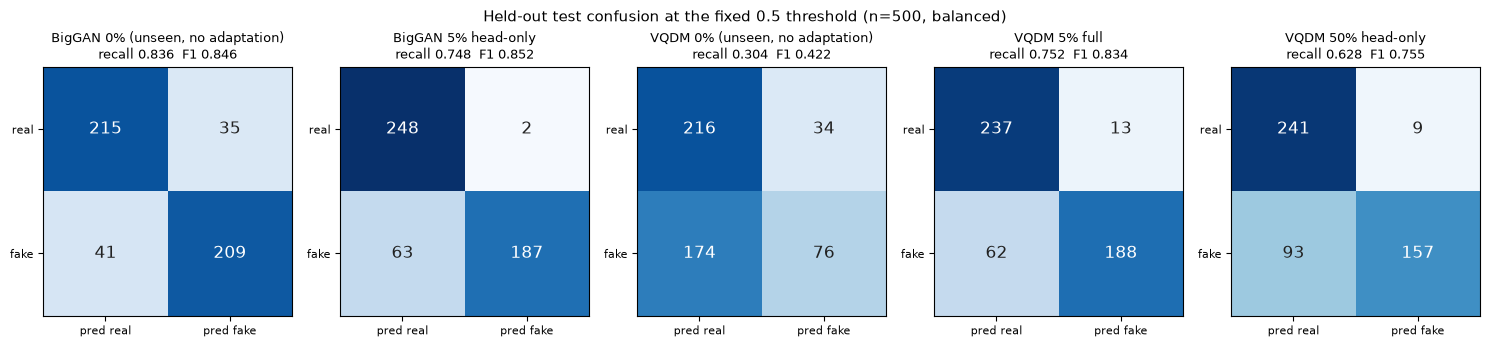

In [27]:
available = [r for r in D.confusion_selection(ctx) if r.get("available")]
largest = max(max(r["true_negative"], r["false_positive"],
                  r["false_negative"], r["true_positive"]) for r in available)

fig, axes = plt.subplots(1, len(available), figsize=(3.0 * len(available), 3.4))
for ax, row in zip(axes, available):
    matrix = [[row["true_negative"], row["false_positive"]],
              [row["false_negative"], row["true_positive"]]]
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=largest)
    for i in range(2):
        for j in range(2):
            value = matrix[i][j]
            ax.text(j, i, str(value), ha="center", va="center", fontsize=12,
                    color="white" if value > largest * 0.55 else "#222222")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred real", "pred fake"], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"], fontsize=8)
    ax.set_title(f"{row['label']}\nrecall {row['recall']:.3f}  F1 {row['f1']:.3f}", fontsize=9)
fig.suptitle("Held-out test confusion at the fixed 0.5 threshold (n=500, balanced)", fontsize=11)
fig.tight_layout()
plt.show()

**Reading.** This is the headline trade-off in its most concrete form. VQDM at 0% misses
most held-out fakes. Full fine-tuning on 100 labelled images and head-only on 1,000 both
repair it, and the cheaper one repairs it further — a difference in missed detections,
not a 0.0014 difference in area under a curve.

Note also the BigGAN 5% head-only column: recall *falls* relative to 0% while F1 rises,
because adaptation bought a large reduction in false positives. Adaptation is not
uniformly beneficial on every metric, and the chapter should not imply it is.

## 9. Validation and training trajectories

Only the trajectories that carry explanatory value: how quickly each depth converges on
the adaptation-validation split, at the smallest budget where the depths differ most.

These are **adaptation-validation** F1, not test F1, and at the 5% budget they are
measured on 160 images. They are shown for convergence behaviour only and no performance
claim rests on them.

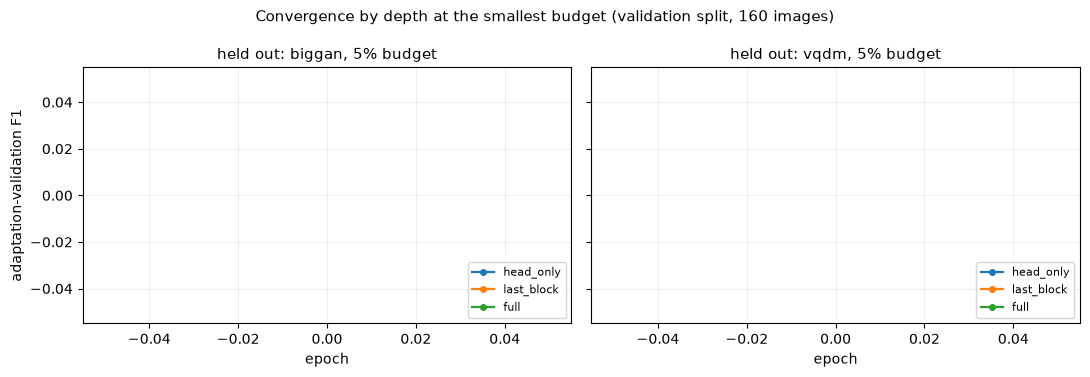

In [28]:
history_rows = []
for record in ctx.ablation_runs():
    generator = ctx.held_out_of(record.run_id)
    for mode in D.DEPTHS:
        path = OUTPUT_ROOT / record.run_id / "cells" / f"{mode}_p05_s42_t42" / "train_history.csv"
        if not path.exists():
            continue
        with path.open() as handle:
            for row in csv.DictReader(handle):
                history_rows.append({
                    "generator": generator, "mode": mode,
                    "epoch": int(row["epoch"]),
                    "validation_f1": float(row["validation_f1"]) if row.get("validation_f1") else None,
                })

history = pd.DataFrame(history_rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, generator in zip(axes, ["biggan", "vqdm"]):
    subset = history[history["generator"] == generator]
    for mode in D.DEPTHS:
        curve = subset[subset["mode"] == mode].sort_values("epoch")
        if curve.empty:
            continue
        ax.plot(curve["epoch"], curve["validation_f1"], marker="o", label=mode,
                linewidth=1.6, markersize=4)
    ax.set_title(f"held out: {generator}, 5% budget", fontsize=11)
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("adaptation-validation F1")
fig.suptitle("Convergence by depth at the smallest budget (validation split, 160 images)",
             fontsize=11)
fig.tight_layout()
plt.show()

## 10. Cross-generator synthesis

One row per held-out generator: the whole story in the columns of a single table.

`cheapest_reaching_0.95_*` uses a **declared** attainment bar rather than a
"within some tolerance of the best" rule, which would hide an arbitrary tolerance inside
a column that looks measured.

In [29]:
synthesis = pd.DataFrame(D.cross_generator_synthesis(ctx))
synthesis.T

,0,1
held_out_generator,biggan,vqdm
head_type,linear,linear
in_distribution_roc_auc,0.9374,0.9664
unseen_0pct_roc_auc,0.9284,0.6746
generalisation_gap,0.0090,0.2918
head_only_5pct,0.9843,0.8200
last_block_5pct,0.9876,0.8671
full_5pct,0.9985,0.9408
head_only_50pct,0.9975,0.9394
best_roc_auc,1.0000,0.9974


## 11. Findings summary

Machine-derived. Every string below is formatted from numbers looked up at render time,
so this section cannot drift from the data the way a hand-written summary would.

The four groups are deliberately separated by how much interpretation each carries.

In [30]:
for heading, items in D.findings(ctx).items():
    print("=" * 78)
    print(heading)
    print("=" * 78)
    for item in items:
        print(f"  - {item}")
    print()

A. Direct measured facts
  - biggan: in-distribution ROC-AUC 0.9374, unseen with no adaptation 0.9284 (n=500, fixed 0.5 threshold for count metrics).
  - biggan: best measured unseen ROC-AUC 1.0000 at full @50%, using 1000 labelled biggan images.
  - vqdm: in-distribution ROC-AUC 0.9664, unseen with no adaptation 0.6746 (n=500, fixed 0.5 threshold for count metrics).
  - vqdm: best measured unseen ROC-AUC 0.9974 at full @50%, using 1000 labelled vqdm images.
  - Reproduction: 30 of 30 head-only comparisons between each ablation and its standalone recovery run agree exactly.
  - VQDM with no adaptation recovers 0.304 of held-out fakes at the 0.5 threshold (174 of 250 missed), so the failure is a missed-detection failure rather than a ranking failure.

B. Derived numerical comparisons
  - biggan: generalisation gap 0.0090 ROC-AUC (0.90 percentage points).
  - vqdm: generalisation gap 0.2918 ROC-AUC (29.18 percentage points).
  - biggan: at 5%, roc_auc runs head_only 0.9843 -> last_block 

### Note on group D

Group D is not a disclaimer section. Each entry is a claim that a reader could
reasonably think this project demonstrated, and does not. In particular the ROC-AUC
version of the "5% full beats 50% head-only" result sits below the reliability floor and
must be written as equivalence at a tenth of the labelling cost; the F1 version and the
missed-detection counts are the forms that survive.